# NPCI Digital Payments Failure Analysis — EDA

Exploring failure patterns in NFS (ATM network) and AEPS (Aadhaar-enabled 
payments) transactions across 107 banks, 2021–2023.

**Data quality note:** During cleaning, two real issues were found and fixed — 
a date-encoding bug (month numbers stored in the day field) and inconsistent 
bank name formatting causing duplicate entries. See `../NOTES.md` and 
`../src/clean_data.py` for details.

In [14]:
! pip install pandas matplotlib seaborn

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/npci_declined_cleaned.csv", parse_dates=["date"])
df.head()

,date,year,month,product,bank,total_volume,approved_pct,bd_pct,td_pct,total_decline_pct
0,2021-01-08,2021,8,NFS,State Bank Of India,109.85,83.91,14.68,0.44,15.12
1,2021-01-08,2021,8,NFS,Union Bank Of India,35.10,82.67,15.44,0.93,16.37
2,2021-01-08,2021,8,NFS,Canara Bank,32.95,79.88,16.90,2.40,19.30
3,2021-01-08,2021,8,NFS,Bank Of Baroda,30.98,81.56,16.73,0.70,17.43
4,2021-01-08,2021,8,NFS,Punjab National Bank,29.26,82.62,15.71,0.68,16.39


## Finding 1: AEPS fails significantly more than NFS

AEPS's technical decline rate is over 3.6x higher than NFS's, consistent 
with its dependence on biometric authentication over often lower-quality 
rural network infrastructure.

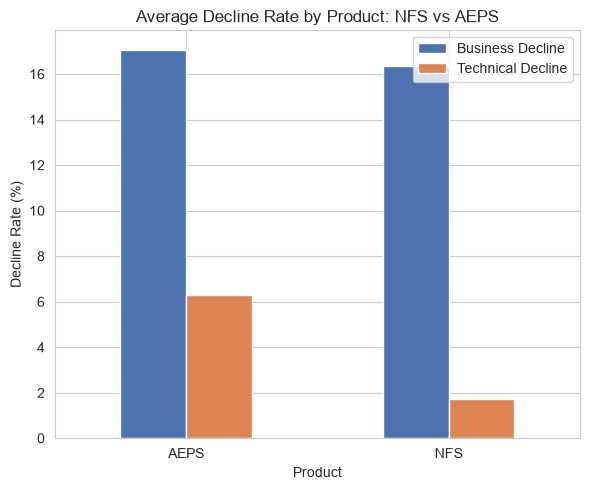

In [16]:
product_summary = df.groupby("product")[["bd_pct", "td_pct"]].mean()

product_summary.plot(kind="bar", figsize=(6, 5), color=["#4C72B0", "#DD8452"])
plt.title("Average Decline Rate by Product: NFS vs AEPS")
plt.ylabel("Decline Rate (%)")
plt.xlabel("Product")
plt.xticks(rotation=0)
plt.legend(["Business Decline", "Technical Decline"])
plt.tight_layout()
plt.savefig("../data/processed/chart_product_comparison.png", dpi=150)
plt.show()

## Finding 2: Regional Rural Banks dominate technical failures

The banks with the highest technical decline rates are almost entirely 
Regional Rural Banks (RRBs), not major national banks — pointing to an 
infrastructure gap between large commercial banks and smaller 
rural-serving institutions.

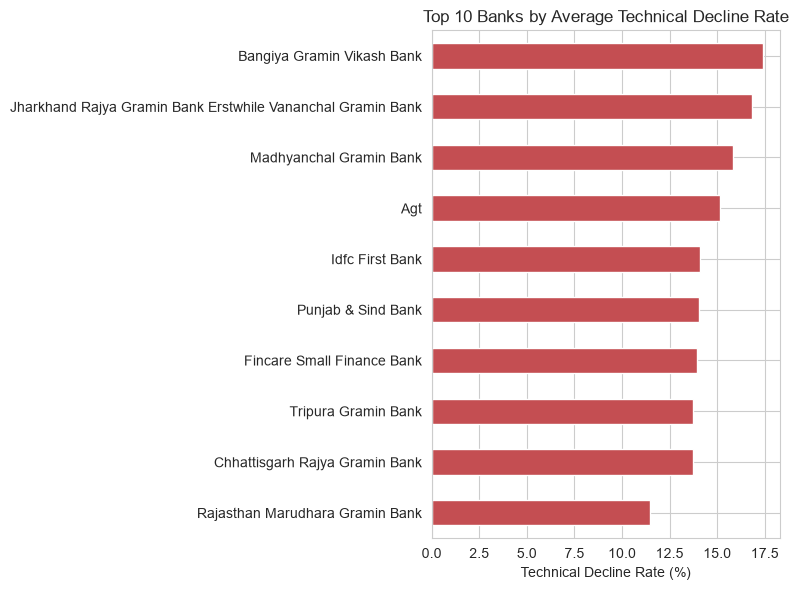

In [17]:
top_td_banks = (
    df.groupby("bank")["td_pct"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 6))
top_td_banks.sort_values().plot(kind="barh", color="#C44E52")
plt.title("Top 10 Banks by Average Technical Decline Rate")
plt.xlabel("Technical Decline Rate (%)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../data/processed/chart_top_td_banks.png", dpi=150)
plt.show()

## Finding 3: Business decline is rising while technical decline falls

Comparing 2021 to 2023, technical decline has trended down (~4.3% → ~3%), 
suggesting real infrastructure improvements. Business decline has 
trended up slightly (~15.7% → ~17.3%), suggesting user-side friction 
(PIN errors, limit breaches) hasn't improved and may be worsening as 
volume grows.

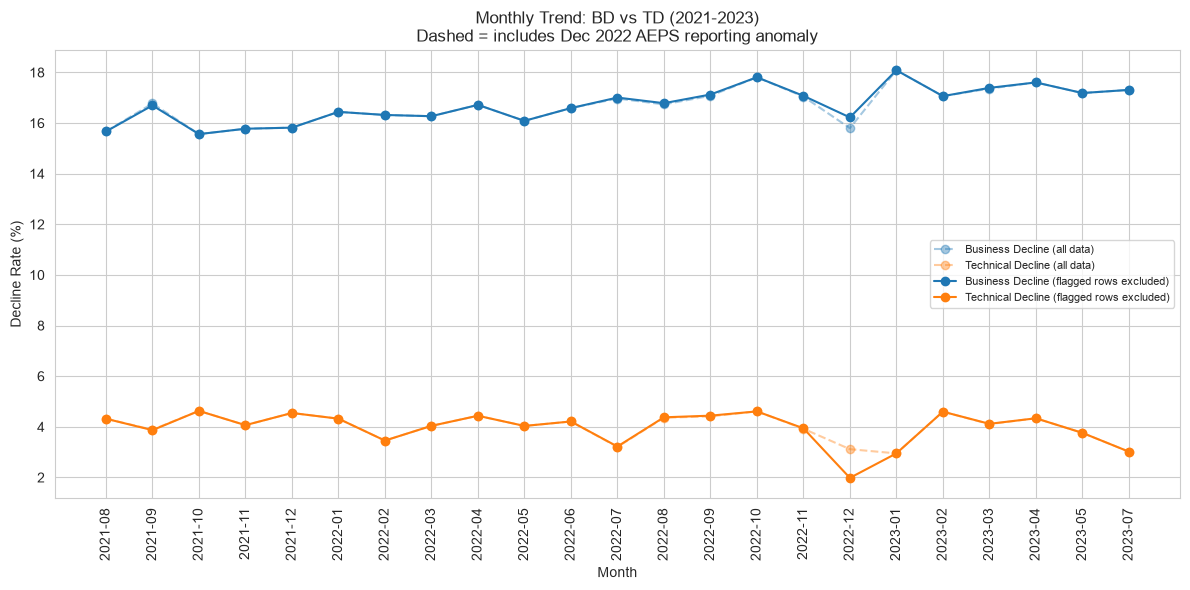

In [20]:
# Reload with the data_quality_flag column now included
df = pd.read_csv("../data/processed/npci_declined_cleaned.csv", parse_dates=["date"])

monthly_trend_all = (
    df.groupby(["year", "month"])[["bd_pct", "td_pct"]]
    .mean()
    .reset_index()
)
monthly_trend_clean = (
    df[df["data_quality_flag"] == False]
    .groupby(["year", "month"])[["bd_pct", "td_pct"]]
    .mean()
    .reset_index()
)

for d in (monthly_trend_all, monthly_trend_clean):
    d["period"] = d["year"].astype(str) + "-" + d["month"].astype(str).str.zfill(2)
    d.sort_values(["year", "month"], inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(monthly_trend_all["period"], monthly_trend_all["bd_pct"], marker="o", label="Business Decline (all data)", alpha=0.4, linestyle="--")
plt.plot(monthly_trend_all["period"], monthly_trend_all["td_pct"], marker="o", label="Technical Decline (all data)", alpha=0.4, linestyle="--")
plt.plot(monthly_trend_clean["period"], monthly_trend_clean["bd_pct"], marker="o", label="Business Decline (flagged rows excluded)", color="#1f77b4")
plt.plot(monthly_trend_clean["period"], monthly_trend_clean["td_pct"], marker="o", label="Technical Decline (flagged rows excluded)", color="#ff7f0e")

plt.title("Monthly Trend: BD vs TD (2021-2023)\nDashed = includes Dec 2022 AEPS reporting anomaly")
plt.xlabel("Month")
plt.ylabel("Decline Rate (%)")
plt.xticks(rotation=90)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../data/processed/chart_monthly_trend.png", dpi=150)
plt.show()

## Finding 4: Volume doesn't guarantee reliability

State Bank of India processes far more volume than any other bank but 
sits at a middling ~20% decline rate. The worst-performing outliers 
(50%+ decline) are all low-volume banks — suggesting high volume 
correlates with more *consistent* performance, but not necessarily the 
*best* performance.

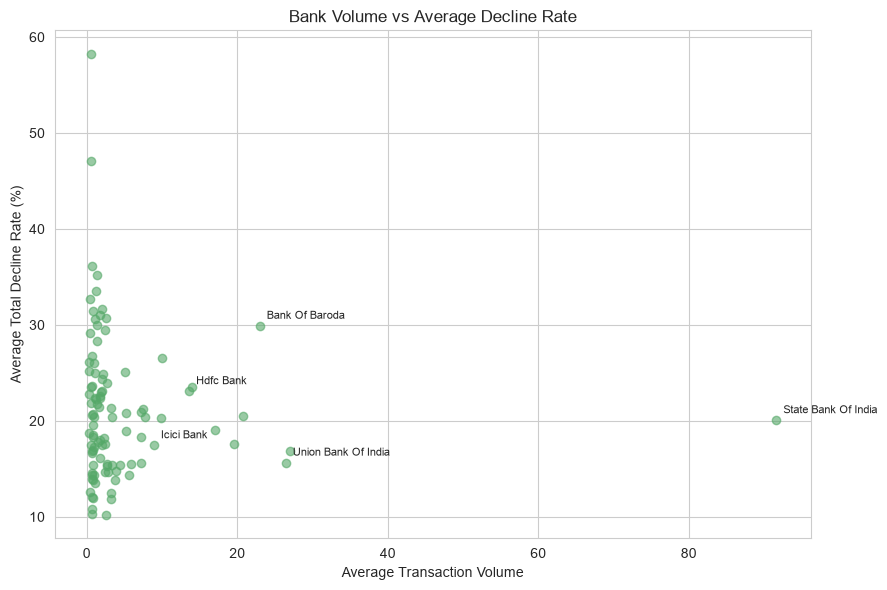

In [19]:
bank_summary = (
    df.groupby("bank")
    .agg(avg_volume=("total_volume", "mean"), avg_decline=("total_decline_pct", "mean"))
    .reset_index()
)

plt.figure(figsize=(9, 6))
plt.scatter(bank_summary["avg_volume"], bank_summary["avg_decline"], alpha=0.6, color="#55A868")

# Label a few notable banks so the chart tells a story, not just dots
notable_banks = ["State Bank Of India", "Bank Of Baroda", "Union Bank Of India", "Hdfc Bank", "Icici Bank"]
for _, row in bank_summary[bank_summary["bank"].isin(notable_banks)].iterrows():
    plt.annotate(row["bank"], (row["avg_volume"], row["avg_decline"]), fontsize=8, xytext=(5, 5), textcoords="offset points")

plt.title("Bank Volume vs Average Decline Rate")
plt.xlabel("Average Transaction Volume")
plt.ylabel("Average Total Decline Rate (%)")
plt.tight_layout()
plt.savefig("../data/processed/chart_volume_vs_decline.png", dpi=150)
plt.show()